# Substrate Classification Pipeline

Authors: Tulio Soto Parra, David Faro, Guido Zolezzi

Based on: *A robust, user-friendly tool for accurate fluvial substrate class estimation*

End-to-end workflow for river substrate classification from orthophotos.

## Pipeline Overview
1. Install dependencies.
2. Configure paths and parameters.
3. Create annotation samples and optional ROI.
4. Extract training features.
5. Train and evaluate the model.
6. Classify the orthophoto.
7. Generate validation samples.
8. Compute final accuracy.

### Step 1: Install Required Packages
Uncomment the line below if you haven't installed dependencies yet.

In [16]:
!pip install -r requirements.txt

### Step 2: Configuration
All paths and hyperparameters are centralized here. You can modify these parameters directly in this cell.

In [ ]:
import os

# ENABLE AUTORELOAD: This ensures changes in src/*.py are automatically picked up
%load_ext autoreload
%autoreload 2
%matplotlib inline

# --- CENTRALIZED CONFIGURATION ---
cfg = {
    # --- PATHS ---
    'paths': {
        'orthophoto': "data/orthophoto.tif",  # Path to the source orthophoto (GeoTIFF)
        'labels_gpkg': "data/sampling_data.gpkg",        # Path to the GeoPackage containing training/test labels *do not modify
        'labels_layer': "annotations",              # Layer name within the labels GeoPackage
        'roi_layer': "roi",                       # Optional ROI layer inside the labels GeoPackage
        'output_dir': "outputs",                    # Base directory for all outputs
        'models_dir': "outputs/models",             # Folder for trained models and feature rankings
        'features_dir': "outputs/features",         # Folder for extracted CSV feature tables
        'maps_dir': "outputs/maps",                 # Folder for final classification rasters
        'validation_dir': "outputs/validation"      # Folder for validation points and accuracy reports
    },

    # --- FEATURE EXTRACTION ---
    'features': {
        'block_size': 50,                           # Window size (px) for calculating features (e.g., 50x50 blocks)
        'tile_size': 1000,                          # Tile size (px) for memory-efficient full-map classification
        'use_spectral': True,                       # Enable color/spectral features (RGB, LAB, Color Invariants)
        'use_glcm': True,                           # Enable GLCM texture features (Contrast, Homogeneity, etc.)
        'use_lbp': True                             # Enable Local Binary Pattern (texture)
    },

    # --- MODELING & TRAINING ---
    'model': {
        'type': "RandomForest",                     # Classifier: 'RandomForest', 'XGBoost', or 'LightGBM'
        'use_class_weighting': True,                # Automatically balance class weights (helpful for rare classes)
        'corr_threshold': 0.9,                      # Remove redundant features with Spearman correlation above this
        'final_feature_count': None,                # Statistical selection (μ + σ > 0). Set to an integer to limit top N.
        'n_splits_cv': 3                            # Kept for backward compatibility; folds are now adaptive in train_pipeline (clamped 3..10)
    },

    # --- VALIDATION (Accuracy Assessment) ---
    'validation': {
        'total_samples': 150,                       # Total validation squares to generate for manual labeling
        'min_samples_per_class': 20,                # Minimum samples required per class for robust stats
        'confidence_level': 0.95                    # Confidence interval for the final accuracy report
    }
}

# Auto-resolve relative paths to the folder where this notebook is located
notebook_dir = os.getcwd()
for key, val in cfg['paths'].items():
    # SKIP layer-name settings as they are inside the GPKG, not file paths
    if key in ('labels_layer', 'roi_layer'):
        continue
    if isinstance(val, str) and not os.path.isabs(val):
        cfg['paths'][key] = os.path.normpath(os.path.join(notebook_dir, val))

print(f"✅ Configuration stabilized. Output directory: {cfg['paths']['output_dir']}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✅ Configuration stabilized. Output directory: /Users/tsotop/Unitn/Substrate/final/Jupyter/outputs


### Step 3: Generate Annotation Sample
Create point samples for manual labeling in GIS software (e.g., QGIS).

The GeoPackage includes three layers: *points*, *annotations*, and an optional *roi* layer. If *roi* is empty, the full domain is used downstream. Draw polygons in *annotations* and, if needed, polygons in *roi* to restrict the workflow to a subset of the map.

In [18]:
from src.annotation import generate_sampling_grid

generate_sampling_grid(
    ortho_path=cfg['paths']['orthophoto'],
    output_path=cfg['paths']['labels_gpkg'],
    grid_rows=5,
    grid_cols=5,
    points_per_cell=5
)

print(f"\n✅ Sampling grid created. Open a GIS software, load your orthophoto and sampling_data.gpkg and proceed with annotations.\n")

Generating sampling grid for /Users/tsotop/Unitn/Substrate/final/Jupyter/data/orthophoto.tif...
Saved to /Users/tsotop/Unitn/Substrate/final/Jupyter/data/sampling_data.gpkg

✅ Sampling grid created. Open a GIS software, load your orthophoto and sampling_data.gpkg and proceed with annotations.



### Step 4: Extract Features
Extract spectral (RGB/LAB), GLCM, and LBP features for the labeled polygons.

Extracting features from /Users/tsotop/Unitn/Substrate/final/Jupyter/data/orthophoto.tif...
Reading labels from: /Users/tsotop/Unitn/Substrate/final/Jupyter/data/sampling_data.gpkg (Layer: annotations)


Extracting (SGL) Features: 100%|██████████████████████████████████| 17/17 [00:07<00:00,  2.26it/s]


Extracted 4824 samples to /Users/tsotop/Unitn/Substrate/final/Jupyter/outputs/features/block_features_ALL.csv

--- Running Class Distribution Analysis ---


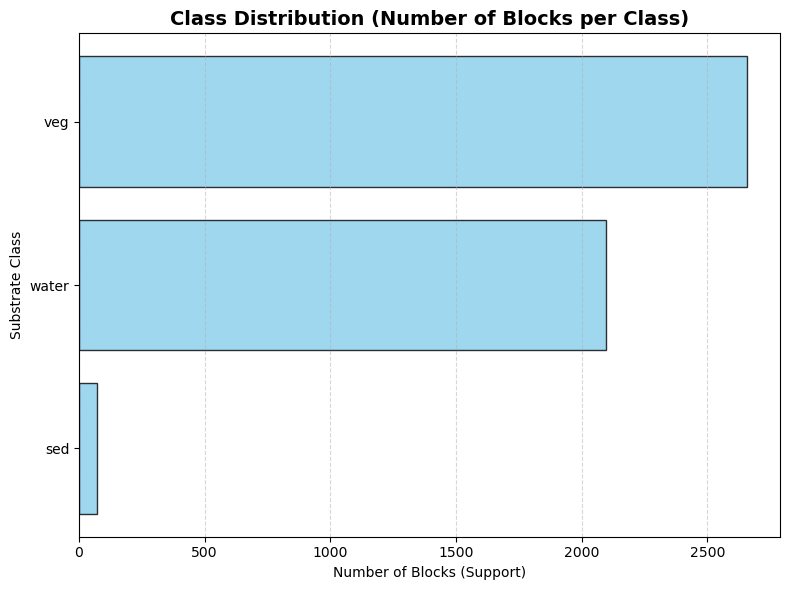

Class counts details:
class
veg      2656
water    2096
sed        72
Name: count, dtype: int64


,label_id,block_row,block_col,mean_r,mean_g,mean_b,mean_hls_l,mean_lab_l,norm_a_star,norm_b_star,...,lbp_lab_l_bin_1,lbp_lab_l_bin_2,lbp_lab_l_bin_3,lbp_lab_l_bin_4,lbp_lab_l_bin_5,lbp_lab_l_bin_6,lbp_lab_l_bin_7,lbp_lab_l_bin_8,lbp_lab_l_bin_9,class
0,0,0,32,8.4176,8.8900,8.3524,8.8884,3.639226,-0.076011,0.061935,...,0.0052,0.0020,0.0168,0.0028,0.0156,0.0004,0.0048,0.9444,0.0076,water
1,0,0,33,20.5956,21.4140,20.9516,21.4928,8.886658,-0.044391,0.015861,...,0.0108,0.0052,0.0276,0.0192,0.0408,0.0136,0.0128,0.8512,0.0164,water
2,0,0,34,33.7156,35.2388,34.3924,35.3352,14.604159,-0.050127,0.017783,...,0.0164,0.0068,0.0388,0.0364,0.0616,0.0268,0.0204,0.7664,0.0224,water
3,0,0,35,45.4128,48.2460,47.7984,48.7396,19.957149,-0.056666,-0.006876,...,0.0148,0.0080,0.0596,0.0816,0.0932,0.0324,0.0220,0.6680,0.0172,water
4,0,0,36,55.7508,59.3676,59.9848,60.1692,24.658802,-0.049232,-0.032595,...,0.0288,0.0092,0.0668,0.0568,0.1120,0.0420,0.0464,0.6052,0.0272,water
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4819,16,8,2,118.4464,123.0412,119.5320,123.3864,51.038967,-0.046905,0.025198,...,0.0296,0.0152,0.1436,0.1852,0.2504,0.0888,0.0780,0.1556,0.0500,water
4820,16,8,3,90.5348,96.5176,93.3232,96.4748,39.692711,-0.071416,0.023881,...,0.0244,0.0124,0.1120,0.1188,0.1728,0.0608,0.0540,0.3904,0.0480,water
4821,16,8,4,45.4920,50.6280,49.5752,50.6136,20.805566,-0.102073,-0.003521,...,0.0180,0.0064,0.0540,0.0460,0.1064,0.0300,0.0344,0.6740,0.0276,water
4822,16,8,5,12.4764,13.6396,13.3640,13.6512,5.611554,-0.086630,0.000367,...,0.0060,0.0024,0.0140,0.0144,0.0304,0.0056,0.0076,0.9060,0.0112,water


In [ ]:
from src.features import run_extraction

features_csv = os.path.join(cfg['paths']['features_dir'], 'block_features_ALL.csv')
run_extraction(
    ortho_path=cfg['paths']['orthophoto'],
    labels_path=cfg['paths']['labels_gpkg'],
    layer_name=cfg['paths']['labels_layer'],
    output_csv=features_csv,
    block_size=cfg['features']['block_size'],
    roi_path=cfg['paths']['labels_gpkg'],
    roi_layer_name=cfg['paths']['roi_layer']
)

### Step 5: Fit Model (Analyze Data)
Perform cross-validation, feature reduction, and train the final Random Forest model.


--- Adaptive CV Fold Selection ---
Min unique polygons in a class: 4
Using n_splits=4 (clamped to [3, 10])

--- Running Correlation Analysis ---
Identified 26 columns to drop (Spearman > 0.9): ['mean_g', 'mean_b', 'mean_hls_l', 'mean_lab_l', 'var_hls_l', 'std_lab_l', 'var_lab_l', 'glcm_hls_l_ASM', 'glcm_hls_l_energy', 'glcm_hls_l_entropy', 'glcm_lab_l_contrast', 'glcm_lab_l_dissimilarity', 'glcm_lab_l_homogeneity', 'glcm_lab_l_ASM', 'glcm_lab_l_energy', 'glcm_lab_l_correlation', 'glcm_lab_l_entropy', 'lbp_hls_l_bin_2', 'lbp_hls_l_bin_9', 'lbp_lab_l_bin_0', 'lbp_lab_l_bin_1', 'lbp_lab_l_bin_2', 'lbp_lab_l_bin_3', 'lbp_lab_l_bin_5', 'lbp_lab_l_bin_8', 'lbp_lab_l_bin_9']
Features remaining after correlation filter: 22
Correlation pruning: 48 -> 22 features (threshold=0.9).

--- Running Cross-Validated Permutation Importance for RandomForest ---
--- PFI Fold 1/4 ---
    PFI calculation complete in 1.71s
    Fold Accuracy: 0.9977
--- PFI Fold 2/4 ---
    PFI calculation complete in 0.32s
 

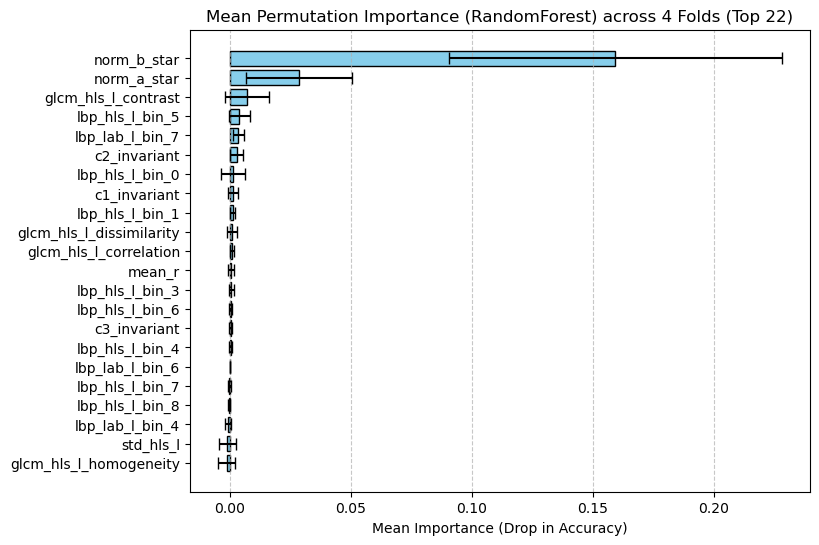


Feature selection results (Requirement: Mean + Std > 0):
- 21 features out of 22 passed the statistical test.

Selected 21 features:
['norm_b_star', 'norm_a_star', 'glcm_hls_l_contrast', 'lbp_hls_l_bin_5', 'lbp_lab_l_bin_7', 'c2_invariant', 'lbp_hls_l_bin_0', 'c1_invariant', 'lbp_hls_l_bin_1', 'glcm_hls_l_dissimilarity', 'glcm_hls_l_correlation', 'mean_r', 'lbp_hls_l_bin_3', 'lbp_hls_l_bin_6', 'c3_invariant', 'lbp_hls_l_bin_4', 'lbp_hls_l_bin_7', 'lbp_hls_l_bin_8', 'lbp_lab_l_bin_4', 'std_hls_l', 'glcm_hls_l_homogeneity']

--- Running Detailed Cross-Validated Performance Report for RandomForest ---
    Fold 1/4 complete.
    Fold 2/4 complete.
    Fold 3/4 complete.
    Fold 4/4 complete.

Class                     | Precision  | Recall     | F1-Score  
-----------------------------------------------------------------
sed                       | 0.743      | 0.692      | 0.714     
veg                       | 0.973      | 0.986      | 0.978     
water                     | 0.970      

In [7]:
from src.modeling import train_pipeline

model, features, cv_scores = train_pipeline(
    features_csv=features_csv,
    output_dir=cfg['paths']['models_dir'],
    model_type=cfg['model']['type'],
    use_spectral=cfg['features']['use_spectral'],
    use_glcm=cfg['features']['use_glcm'],
    use_lbp=cfg['features']['use_lbp'],
    use_class_weighting=cfg['model']['use_class_weighting'],
    corr_threshold=cfg['model']['corr_threshold'],
    final_feature_count=cfg['model']['final_feature_count'],
    n_splits=cfg['model']['n_splits_cv'],
    figsize=(8, 6) 
)

### Step 6: Classify Map
Classify the full orthophoto using the trained model.

In [ ]:
from src.inference import run_inference

output_raster = os.path.join(cfg['paths']['maps_dir'], 'classified_map.tif')
run_inference(
    ortho_path=cfg['paths']['orthophoto'],
    model_path=os.path.join(cfg['paths']['models_dir'], 'final_model.joblib'),
    feat_path=os.path.join(cfg['paths']['models_dir'], 'final_model_features.joblib'),
    class_map_path=os.path.join(cfg['paths']['models_dir'], 'final_class_mapping.joblib'),
    output_raster=output_raster,
    block_size=cfg['features']['block_size'],
    tile_size=cfg['features']['tile_size'],
    roi_path=cfg['paths']['labels_gpkg'],
    roi_layer_name=cfg['paths']['roi_layer']
)

Processing: 100%|███████████████████████████████████████████████| 312/312 [02:58<00:00,  1.75it/s]

Classification saved to /Users/tsotop/Unitn/Substrate/final/Jupyter/outputs/maps/classified_map.tif
Class dictionary saved to /Users/tsotop/Unitn/Substrate/final/Jupyter/outputs/maps/class_dictionary.json

Class Dictionary (pixel value → class name):
    0 → sed
    1 → veg
    2 → water


### Step 7: Generate Validation Set
Generate stratified validation squares from the classified map.

Two files are written: one for manual labels and one with model metadata.

In [ ]:
from src.validation import generate_validation_points

class_map_path = os.path.join(cfg['paths']['models_dir'], 'final_class_mapping.joblib')

generate_validation_points(
    map_path=os.path.join(cfg['paths']['maps_dir'], 'classified_map.tif'),
    class_map_path=class_map_path,
    output_dir=cfg['paths']['validation_dir'],
    total_samples=cfg['validation']['total_samples'],
    min_per_class=cfg['validation']['min_samples_per_class'],
    square_size_px=1,
    roi_path=cfg['paths']['labels_gpkg'],
    roi_layer_name=cfg['paths']['roi_layer']
 )


Generating validation sample from /Users/tsotop/Unitn/Substrate/final/Jupyter/outputs/maps/classified_map.tif...
Saved 168 validation squares to:
  → /Users/tsotop/Unitn/Substrate/final/Jupyter/outputs/validation/validation_true_annotations.gpkg  (fill 'true_label' in QGIS)
  → /Users/tsotop/Unitn/Substrate/final/Jupyter/outputs/validation/validation_modeled.gpkg  (model predictions — keep hidden during annotation)

Class Dictionary (pixel value → class name):
    0 → sed
    1 → veg
    2 → water


### Step 8: Final Validation
Calculate the design-based (unbiased) accuracy of the map after manual labeling.

In [ ]:
from src.validation import calculate_accuracy

results, acc, me = calculate_accuracy(
    annotations_path=os.path.join(cfg['paths']['validation_dir'], 'validation_true_annotations.gpkg'),
    modeled_path=os.path.join(cfg['paths']['validation_dir'], 'validation_modeled.gpkg'),
    output_dir=cfg['paths']['validation_dir'],
    confidence=cfg['validation']['confidence_level']
)


DataLayerError: Layer 'blind_annotation' could not be opened